# Projeto: Consumo de Café e Qualidade do Sono (Health&Life Analytics)
## Parte #1: Análise Exploratória de Dados (EDA)

In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 10

### 1.1 Carregamento dos Dados

In [ ]:
data_path = 'data/synthetic_coffee_health_10000.csv'
if not os.path.exists(data_path):
    data_path = '../data/synthetic_coffee_health_10000.csv'


df = pd.read_csv(data_path, keep_default_na=False)
df.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.50,328.10,7.50,Good,24.90,78,Low,14.50,None,Other,0,0
1,2,33,Male,Germany,1.00,94.10,6.20,Good,20.00,67,Low,11.00,None,Service,0,0
2,3,42,Male,Brazil,5.30,503.70,5.90,Fair,22.70,59,Medium,11.20,Mild,Office,0,0
3,4,53,Male,Germany,2.60,249.20,7.30,Good,24.70,71,Low,6.60,Mild,Other,0,0
4,5,32,Female,Spain,3.10,298.00,5.30,Fair,24.10,76,Medium,8.50,Mild,Student,0,1


### 1.2 Auditoria Estrutural: Dimensões, Tipos, Nulos e Duplicados

In [25]:
print(f"Dimensões do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")

df.info()
print(f"\nRegistros duplicados: {df.duplicated().sum()}")

resumo_qualidade = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    'Nulo_%': (df.isnull().sum() / len(df)) * 100,
    'Valores_Unicos': df.nunique()
})

Dimensões do dataset: 10000 linhas x 16 colunas
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  str    
 3   Country                  10000 non-null  str    
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  str    
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  str    
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            10000 non-null  str    
 13  Occupation               10000 non-null 

### 1.3 Estatísticas Descritivas Iniciais

In [ ]:
colunas_numericas = [
    'Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 
    'BMI', 'Heart_Rate', 'Physical_Activity_Hours', 'Smoking', 'Alcohol_Consumption'
]

estatisticas = df[colunas_numericas].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
estatisticas['IQR'] = estatisticas['75%'] - estatisticas['25%']
display(estatisticas)

,count,mean,std,min,25%,50%,75%,max,IQR
Age,10000.00,34.95,11.16,18.00,26.00,34.00,43.00,80.00,17.00
Coffee_Intake,10000.00,2.51,1.45,0.00,1.50,2.50,3.50,8.20,2.00
Caffeine_mg,10000.00,238.41,137.75,0.00,138.75,235.40,332.02,780.30,193.27
Sleep_Hours,10000.00,6.64,1.22,3.00,5.80,6.60,7.50,10.00,1.70
BMI,10000.00,23.99,3.91,15.00,21.30,24.00,26.60,38.20,5.30
Heart_Rate,10000.00,70.62,9.82,50.00,64.00,71.00,77.00,109.00,13.00
Physical_Activity_Hours,10000.00,7.49,4.32,0.00,3.70,7.50,11.20,15.00,7.50
Smoking,10000.00,0.20,0.40,0.00,0.00,0.00,0.00,1.00,0.00
Alcohol_Consumption,10000.00,0.30,0.46,0.00,0.00,0.00,1.00,1.00,1.00


### 1.4 Distribuição das Variáveis Numéricas (Histogramas e Boxplots)

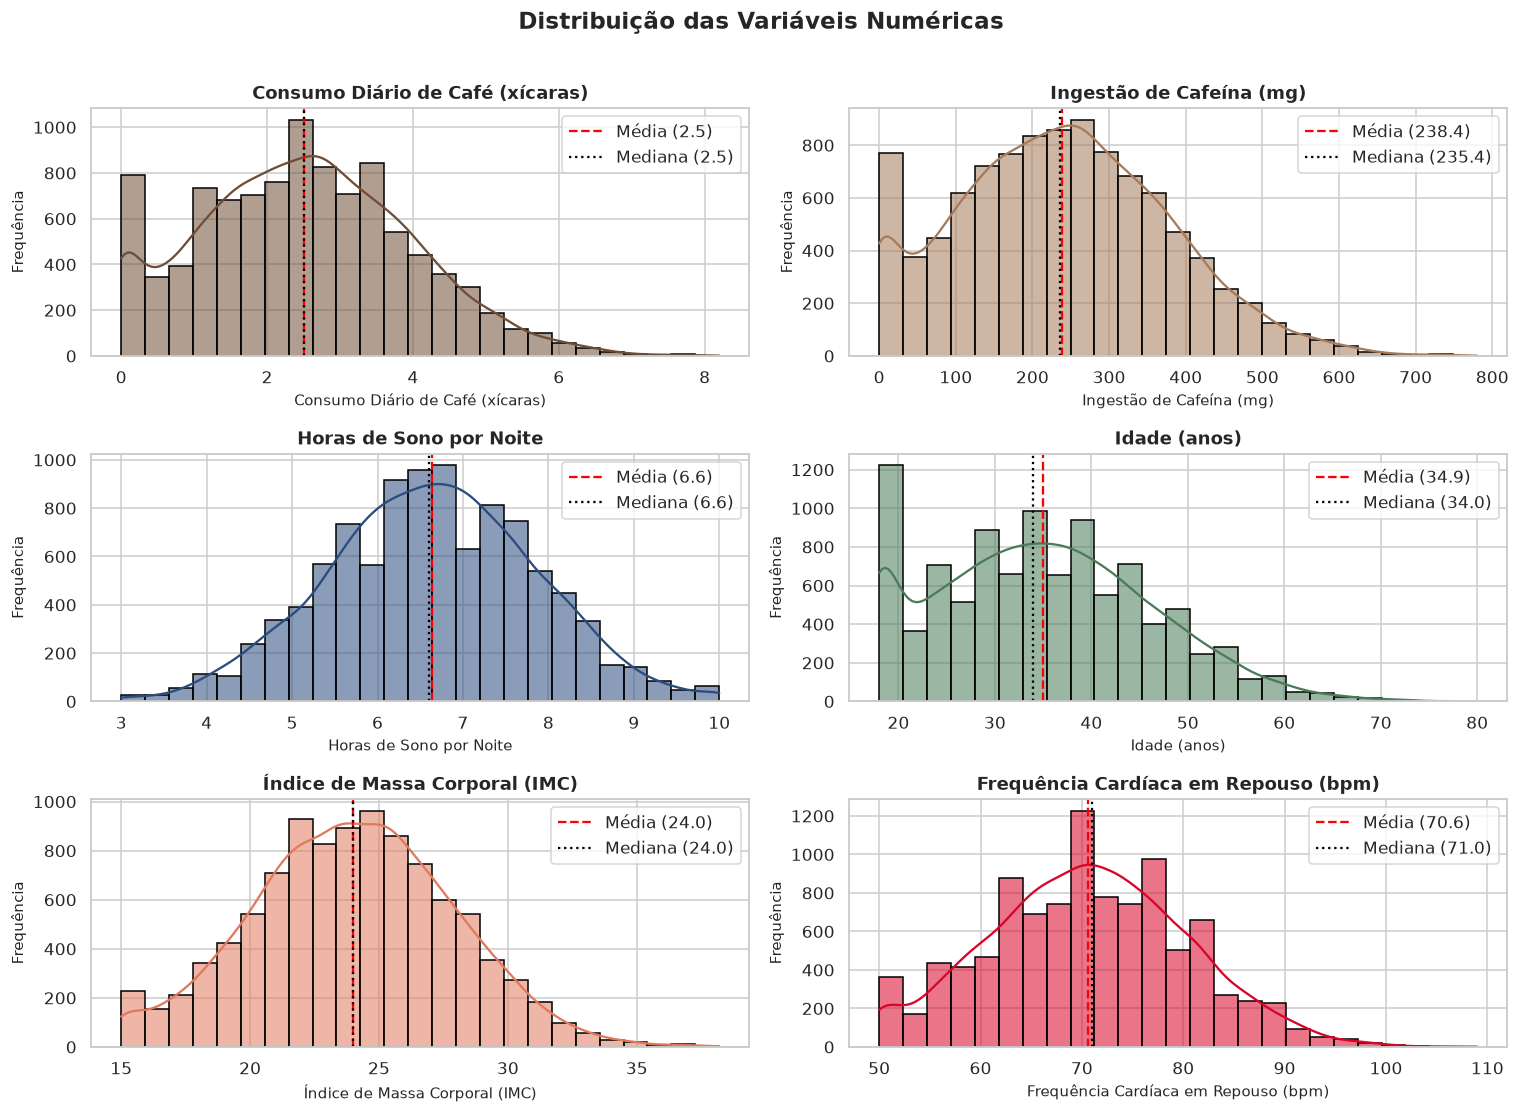

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Distribuição das Variáveis Numéricas', fontsize=15, fontweight='bold', y=1.01)

variaveis_hist = [
    ('Coffee_Intake', 'Consumo Diário de Café (xícaras)', '#6F4E37'),
    ('Caffeine_mg', 'Ingestão de Cafeína (mg)', '#A67B5B'),
    ('Sleep_Hours', 'Horas de Sono por Noite', '#2B4C7E'),
    ('Age', 'Idade (anos)', '#4A7C59'),
    ('BMI', 'Índice de Massa Corporal (IMC)', '#E07A5F'),
    ('Heart_Rate', 'Frequência Cardíaca em Repouso (bpm)', '#D90429')
]

for ax, (col, label, color) in zip(axes.flatten(), variaveis_hist):
    sns.histplot(df[col], kde=True, ax=ax, color=color, edgecolor='black', alpha=0.55, bins=25)
    media = df[col].mean()
    mediana = df[col].median()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5, label=f'Média ({media:.1f})')
    ax.axvline(mediana, color='black', linestyle=':', linewidth=1.5, label=f'Mediana ({mediana:.1f})')
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('Frequência')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

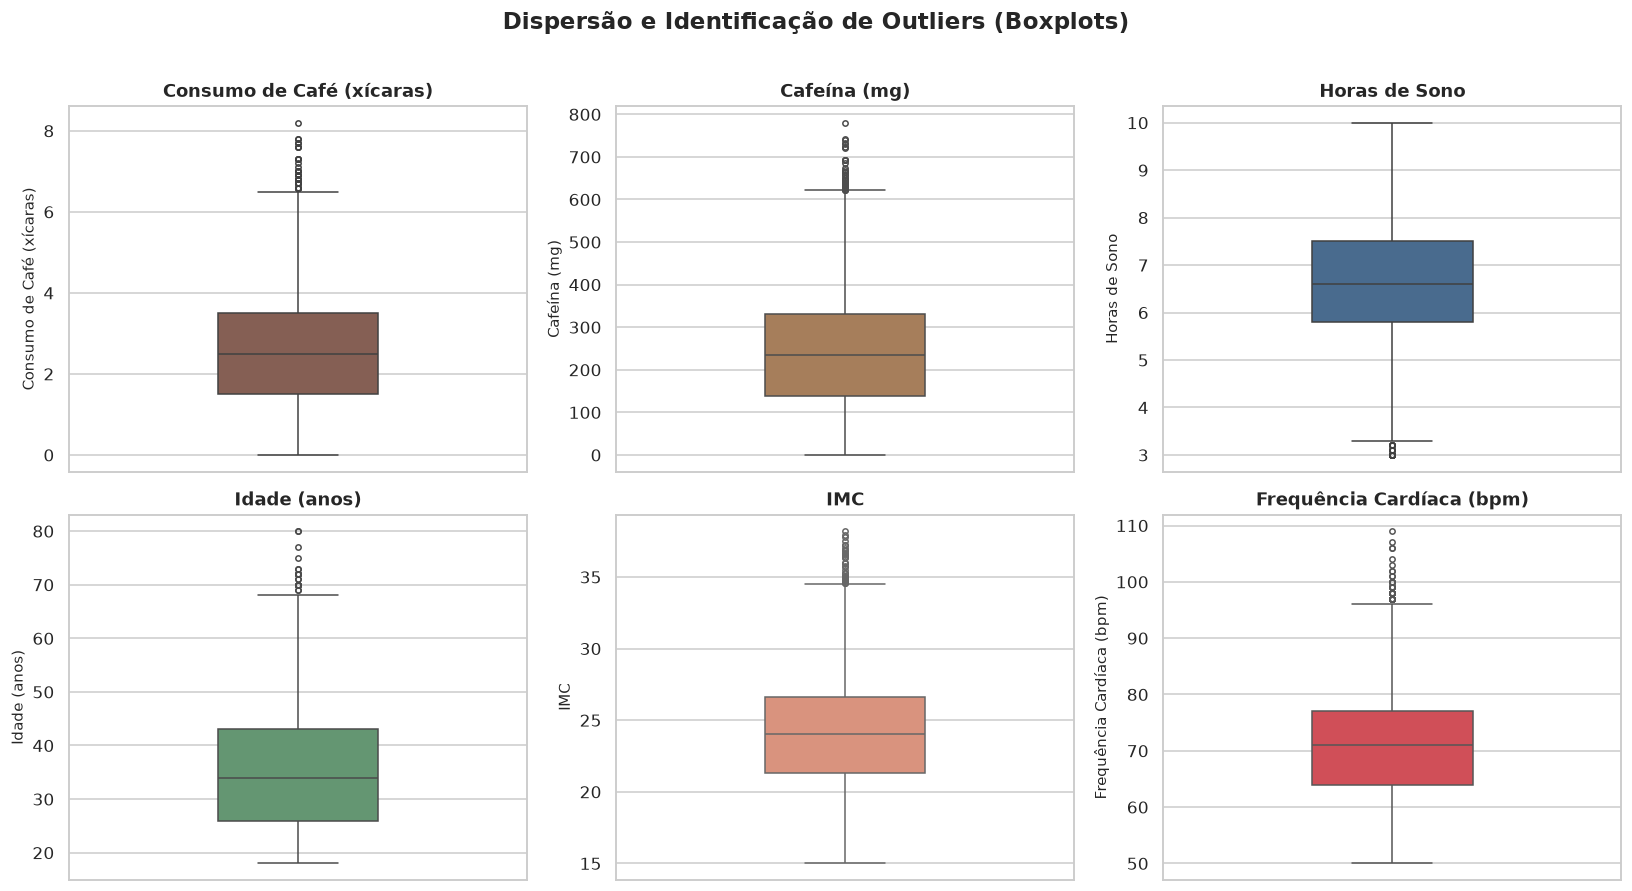

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Dispersão e Identificação de Outliers (Boxplots)', fontsize=15, fontweight='bold', y=1.01)

variaveis_box = [
    ('Coffee_Intake', 'Consumo de Café (xícaras)', '#8D5B4C'),
    ('Caffeine_mg', 'Cafeína (mg)', '#B37D4E'),
    ('Sleep_Hours', 'Horas de Sono', '#3D6B99'),
    ('Age', 'Idade (anos)', '#5C9E6E'),
    ('BMI', 'IMC', '#E88B6F'),
    ('Heart_Rate', 'Frequência Cardíaca (bpm)', '#E63946')
]

for ax, (col, label, color) in zip(axes.flatten(), variaveis_box):
    sns.boxplot(y=df[col], ax=ax, color=color, width=0.35, fliersize=3.5)
    ax.set_title(label)
    ax.set_ylabel(label)


plt.tight_layout()
plt.show()

### 1.5 Frequência das Variáveis Categóricas (Barras e Proporções)

/tmp/ipykernel_9614/2433284633.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sleep_Quality', data=df, order=ordem_sono, ax=axes[0, 0], palette=paleta_sono)
/tmp/ipykernel_9614/2433284633.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Stress_Level', data=df, order=ordem_estresse, ax=axes[0, 1], palette=paleta_estresse)
/tmp/ipykernel_9614/2433284633.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Health_Issues', data=df, order=ordem_saude, ax=axes[1, 0], palette='Blues_r')
/tmp/ipykernel_9614/2433284633.py:50: 

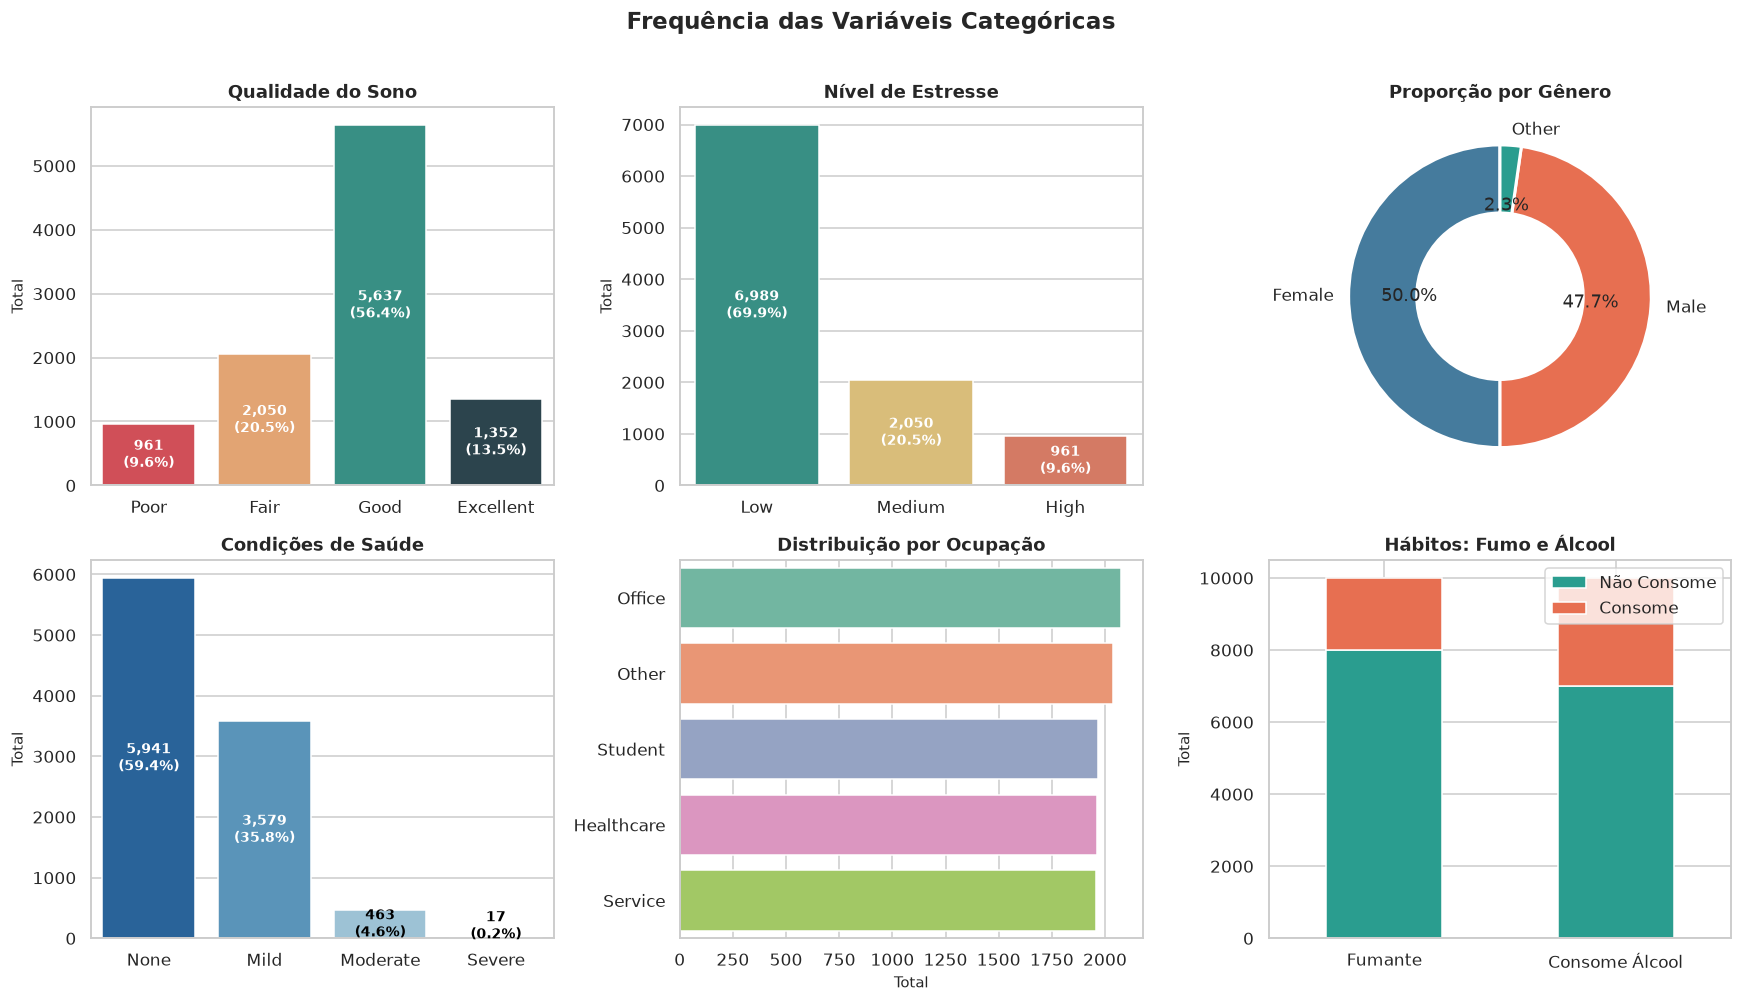

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Frequência das Variáveis Categóricas', fontsize=15, fontweight='bold', y=1.01)

ordem_sono = ['Poor', 'Fair', 'Good', 'Excellent']
paleta_sono = {'Poor': '#E63946', 'Fair': '#F4A261', 'Good': '#2A9D8F', 'Excellent': '#264653'}
sns.countplot(x='Sleep_Quality', data=df, order=ordem_sono, ax=axes[0, 0], palette=paleta_sono)
axes[0, 0].set_title('Qualidade do Sono')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Total')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height()):,}\n({p.get_height()/len(df):.1%})',
                        (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', color='white', fontweight='bold', fontsize=9)


ordem_estresse = ['Low', 'Medium', 'High']
paleta_estresse = {'Low': '#2A9D8F', 'Medium': '#E9C46A', 'High': '#E76F51'}
sns.countplot(x='Stress_Level', data=df, order=ordem_estresse, ax=axes[0, 1], palette=paleta_estresse)
axes[0, 1].set_title('Nível de Estresse')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Total')
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f'{int(p.get_height()):,}\n({p.get_height()/len(df):.1%})',
                        (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', color='white', fontweight='bold', fontsize=9)


contagem_genero = df['Gender'].value_counts()
axes[0, 2].pie(contagem_genero, labels=contagem_genero.index, autopct='%1.1f%%',
               colors=['#457B9D', '#E76F51', '#2A9D8F'], startangle=90,
               wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2))
axes[0, 2].set_title('Proporção por Gênero')



ordem_saude = ['None', 'Mild', 'Moderate', 'Severe']
sns.countplot(x='Health_Issues', data=df, order=ordem_saude, ax=axes[1, 0], palette='Blues_r')
axes[1, 0].set_title('Condições de Saúde')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('Total')
for p in axes[1, 0].patches:
    h = p.get_height()
    if h > 0:
        axes[1, 0].annotate(f'{int(h):,}\n({h/len(df):.1%})',
                            (p.get_x() + p.get_width() / 2., max(h / 2, 200)),
                            ha='center', va='center', color='white' if h > 1000 else 'black',
                            fontweight='bold', fontsize=9)



sns.countplot(y='Occupation', data=df, ax=axes[1, 1], palette='Set2',
              order=df['Occupation'].value_counts().index)
axes[1, 1].set_title('Distribuição por Ocupação')
axes[1, 1].set_xlabel('Total')
axes[1, 1].set_ylabel('')



df_habitos = pd.DataFrame({
    'Não Consome': [(df['Smoking'] == 0).sum(), (df['Alcohol_Consumption'] == 0).sum()],
    'Consome': [(df['Smoking'] == 1).sum(), (df['Alcohol_Consumption'] == 1).sum()]
}, index=['Fumante', 'Consome Álcool'])
df_habitos.plot(kind='bar', stacked=True, ax=axes[1, 2], color=['#2A9D8F', '#E76F51'], edgecolor='white')
axes[1, 2].set_title('Hábitos: Fumo e Álcool')
axes[1, 2].set_ylabel('Total')
axes[1, 2].legend(loc='upper right')
axes[1, 2].tick_params(axis='x', rotation=0)



plt.tight_layout();
plt.show();

### 1.6 Análise de Correlações Numéricas (Heatmap)

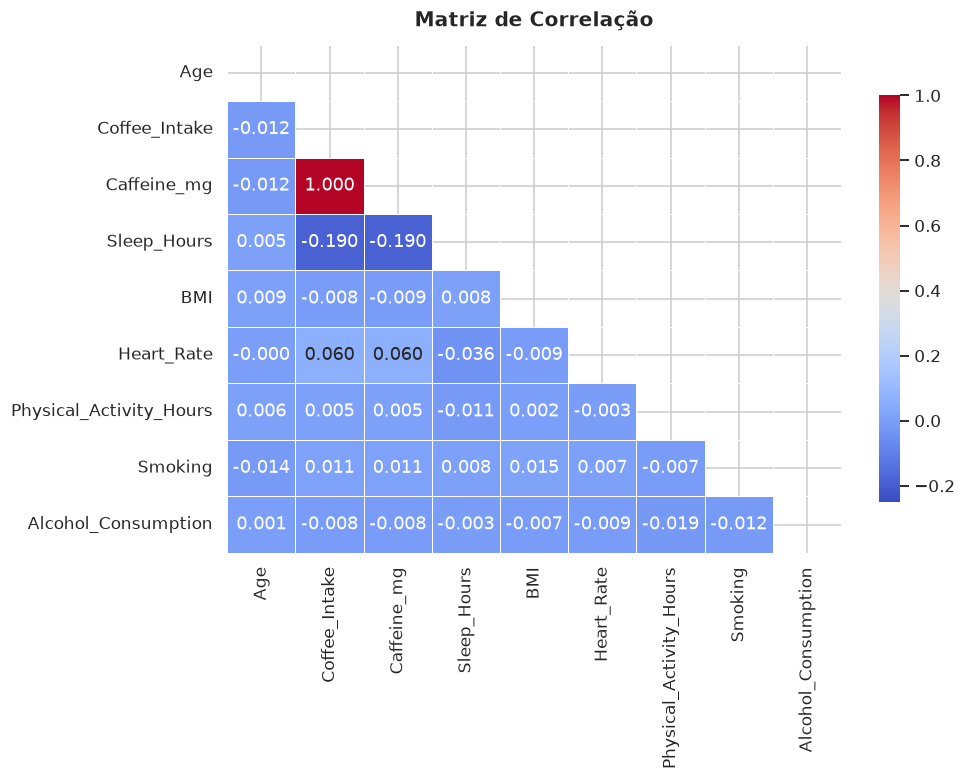

Correlações com Horas de Sono (Sleep_Hours):
Caffeine_mg               -0.19
Coffee_Intake             -0.19
Heart_Rate                -0.04
Physical_Activity_Hours   -0.01
Alcohol_Consumption       -0.00
Age                        0.01
Smoking                    0.01
BMI                        0.01
Sleep_Hours                1.00
Name: Sleep_Hours, dtype: float64


In [ ]:
matriz_corr = df[colunas_numericas].corr()


plt.figure(figsize=(9, 6))
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(matriz_corr, mask=mascara, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-0.25, vmax=1.0, cbar_kws={'shrink': 0.8}, linewidths=0.5)
plt.title('Matriz de Correlação', fontsize=13, fontweight='bold', pad=12)
plt.show()


print("Correlações com Horas de Sono (Sleep_Hours):")
print(matriz_corr['Sleep_Hours'].sort_values())

### 1.7 Cruzamento Inicial: Consumo de Café, Sono e Estresse

In [ ]:
resumo_sono = df.groupby('Sleep_Quality')[['Sleep_Hours', 'Coffee_Intake', 'Caffeine_mg']].agg(['mean', 'median', 'std'])
display(resumo_sono.loc[['Poor', 'Fair', 'Good', 'Excellent']])

tabela_cruzada_estresse = pd.crosstab(df['Stress_Level'], df['Sleep_Quality'], normalize='index') * 100
display(tabela_cruzada_estresse[['Poor', 'Fair', 'Good', 'Excellent']].loc[['High', 'Medium', 'Low']])

Sleep_Hours             Coffee_Intake             Caffeine_mg  \
                     mean median  std          mean median  std        mean   
Sleep_Quality                                                                 
Poor                 4.45   4.60 0.46          2.98   3.00 1.49      283.04   
Fair                 5.58   5.60 0.28          2.76   2.80 1.46      262.74   
Good                 6.92   6.90 0.55          2.45   2.40 1.42      232.45   
Excellent            8.59   8.50 0.50          2.05   2.00 1.36      194.66   

                             
              median    std  
Sleep_Quality                
Poor          281.30 141.93  
Fair          263.30 138.54  
Good          229.60 134.92  
Excellent     186.10 129.19

Sleep_Quality,Poor,Fair,Good,Excellent
Stress_Level,,,,
High,100.00,0.00,0.00,0.00
Medium,0.00,100.00,0.00,0.00
Low,0.00,0.00,80.66,19.34


## Parte #2: Visualização e Insights
Nesta etapa são construídos gráficos comparativos, análises segmentadas por grupos (gênero, idade, ocupação) e investigações multivariadas relacionando café, estresse e sono.

### 2.1 Gráficos Comparativos: Café e Cafeína vs. Horas de Sono

/tmp/ipykernel_9614/1551903598.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Sleep_Quality", y="Coffee_Intake", data=df, order=ordem_sono,


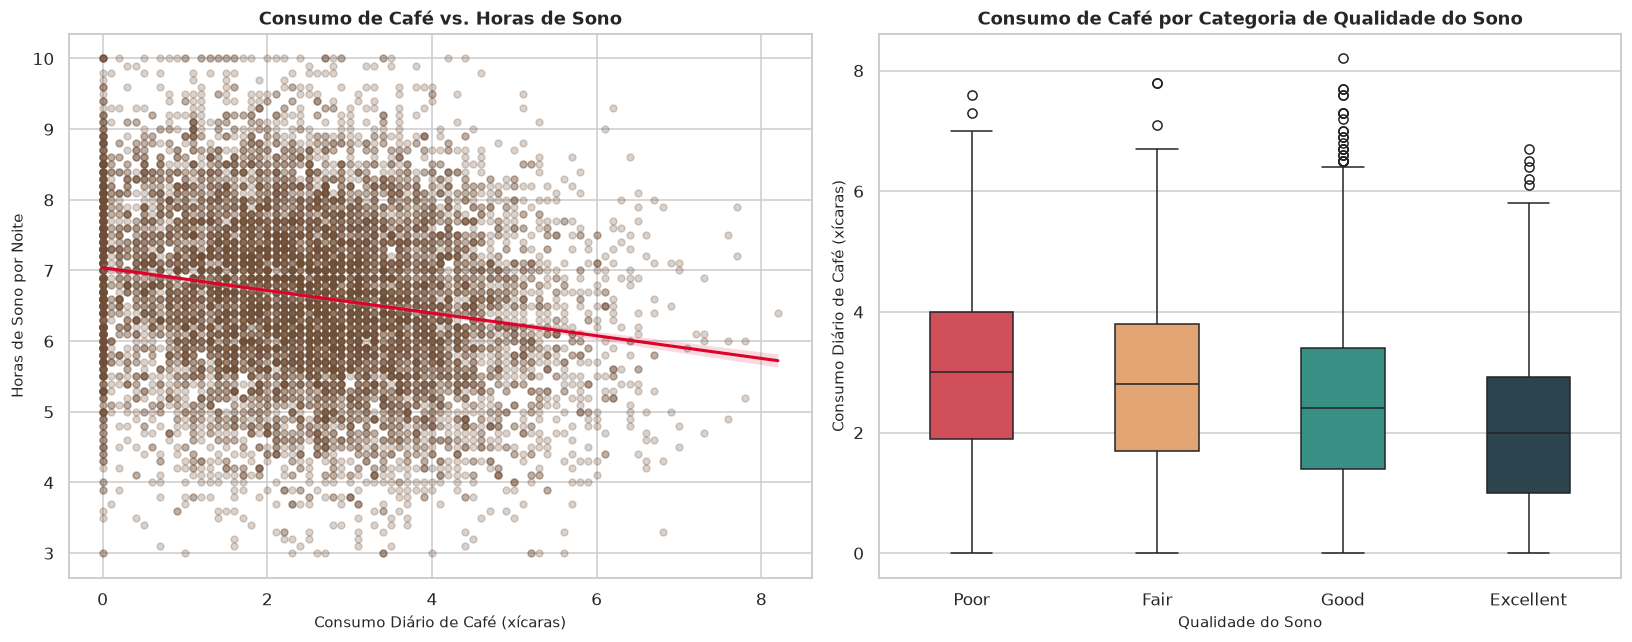

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.regplot(x="Coffee_Intake", y="Sleep_Hours", data=df, ax=axes[0],
            scatter_kws={"alpha": 0.25, "color": "#6F4E37", "s": 20},
            line_kws={"color": "#D90429", "linewidth": 2})
axes[0].set_title("Consumo de Café vs. Horas de Sono")
axes[0].set_xlabel("Consumo Diário de Café (xícaras)")
axes[0].set_ylabel("Horas de Sono por Noite")

ordem_sono = ["Poor", "Fair", "Good", "Excellent"]
paleta_sono = {"Poor": "#E63946", "Fair": "#F4A261", "Good": "#2A9D8F", "Excellent": "#264653"}
sns.boxplot(x="Sleep_Quality", y="Coffee_Intake", data=df, order=ordem_sono,
            palette=paleta_sono, ax=axes[1], width=0.45)
axes[1].set_title("Consumo de Café por Categoria de Qualidade do Sono")
axes[1].set_xlabel("Qualidade do Sono")
axes[1].set_ylabel("Consumo Diário de Café (xícaras)")

plt.tight_layout()
plt.show()

### 2.2 Análise Segmentada por Gênero, Faixa Etária e Ocupação

/tmp/ipykernel_9614/49506219.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Gender", y="Sleep_Hours", data=df, ax=axes[0], palette="Set2", width=0.4)
/tmp/ipykernel_9614/49506219.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Age_Group", y="Sleep_Hours", data=sono_idade, ax=axes[1], palette="Blues_d")
/tmp/ipykernel_9614/49506219.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y="Occupation", x="Sleep_Hours", data=df, ax=axes[2], palette="Pastel1", orient="h")


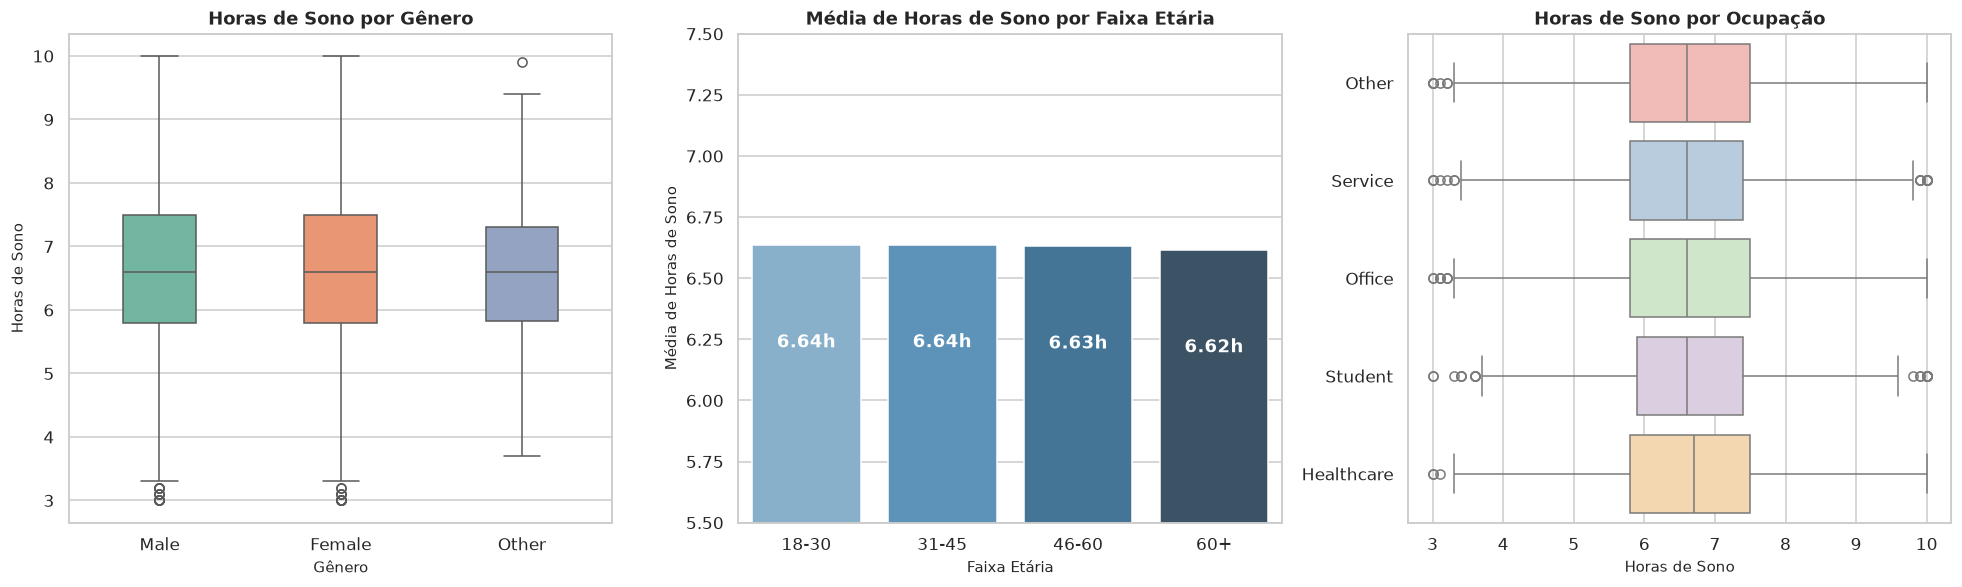

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))


sns.boxplot(x="Gender", y="Sleep_Hours", data=df, ax=axes[0], palette="Set2", width=0.4)
axes[0].set_title("Horas de Sono por Gênero")
axes[0].set_xlabel("Gênero")
axes[0].set_ylabel("Horas de Sono")

df["Age_Group"] = pd.cut(df["Age"], bins=[17, 30, 45, 60, 100], labels=["18-30", "31-45", "46-60", "60+"])
sono_idade = df.groupby("Age_Group", observed=False)["Sleep_Hours"].mean().reset_index()
sns.barplot(x="Age_Group", y="Sleep_Hours", data=sono_idade, ax=axes[1], palette="Blues_d")
axes[1].set_title("Média de Horas de Sono por Faixa Etária")
axes[1].set_xlabel("Faixa Etária")
axes[1].set_ylabel("Média de Horas de Sono")
axes[1].set_ylim(5.5, 7.5)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}h",
                     (p.get_x() + p.get_width() / 2., p.get_height() - 0.4),
                     ha="center", va="center", color="white", fontweight="bold")

sns.boxplot(y="Occupation", x="Sleep_Hours", data=df, ax=axes[2], palette="Pastel1", orient="h")
axes[2].set_title("Horas de Sono por Ocupação")
axes[2].set_xlabel("Horas de Sono")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

### 2.3 Análise Multivariada: Interação Café, Estresse e Sono

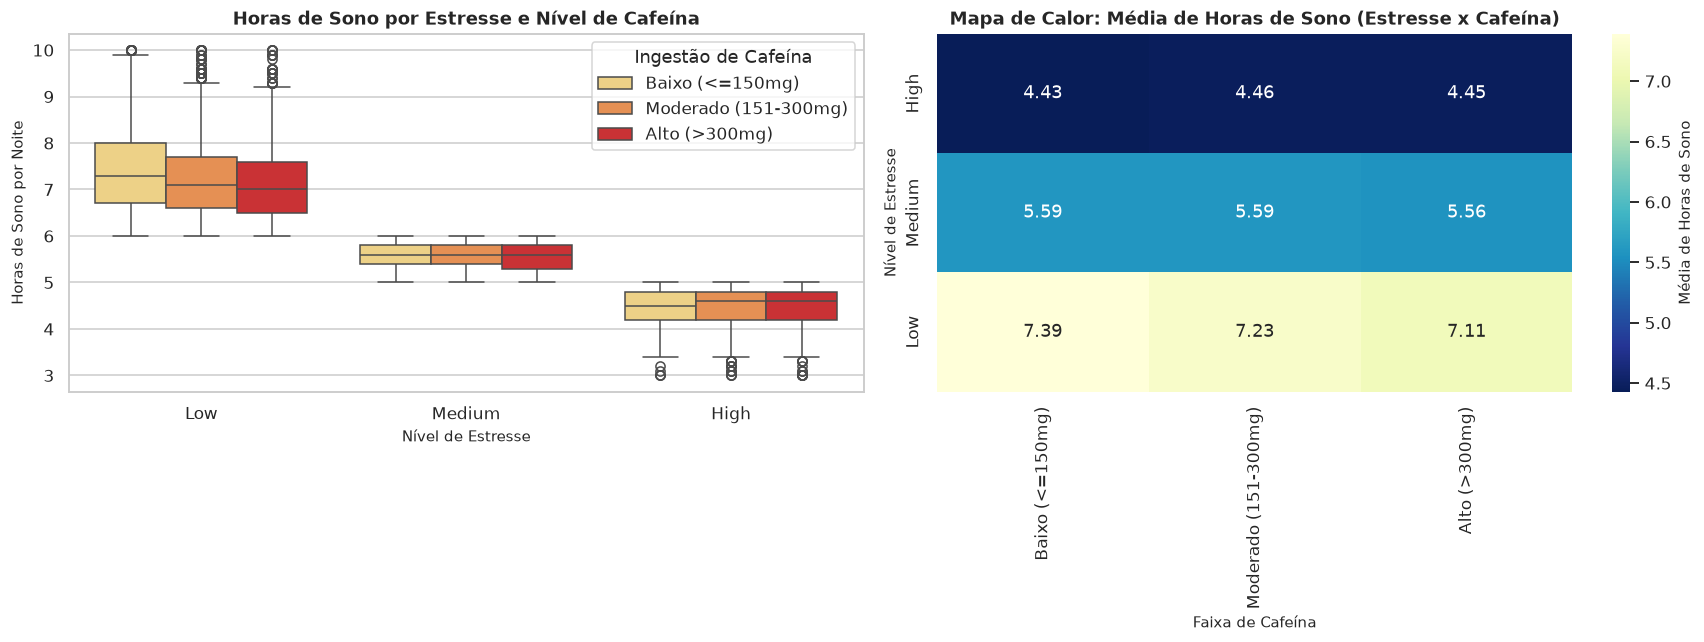

In [30]:
df["Caffeine_Tier"] = pd.cut(df["Caffeine_mg"], bins=[-1, 150, 300, 1000],
                             labels=["Baixo (<=150mg)", "Moderado (151-300mg)", "Alto (>300mg)"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x="Stress_Level", y="Sleep_Hours", hue="Caffeine_Tier", data=df,
            order=["Low", "Medium", "High"], palette="YlOrRd", ax=axes[0])
axes[0].set_title("Horas de Sono por Estresse e Nível de Cafeína")
axes[0].set_xlabel("Nível de Estresse")
axes[0].set_ylabel("Horas de Sono por Noite")
axes[0].legend(title="Ingestão de Cafeína", loc="upper right")

pivot_sono = df.pivot_table(index="Stress_Level", columns="Caffeine_Tier", values="Sleep_Hours", aggfunc="mean", observed=False)
pivot_sono = pivot_sono.loc[["High", "Medium", "Low"]]
sns.heatmap(pivot_sono, annot=True, fmt=".2f", cmap="YlGnBu_r", ax=axes[1], cbar_kws={"label": "Média de Horas de Sono"})
axes[1].set_title("Mapa de Calor: Média de Horas de Sono (Estresse x Cafeína)")
axes[1].set_xlabel("Faixa de Cafeína")
axes[1].set_ylabel("Nível de Estresse")

plt.tight_layout()
plt.show()

### 2.4 Análise Comparativa de Extremos de Consumo e Indicadores de Saúde

In [32]:
p20_cafe = df["Coffee_Intake"].quantile(0.20)
p80_cafe = df["Coffee_Intake"].quantile(0.80)

grupo_baixo = df[df["Coffee_Intake"] <= p20_cafe]
grupo_alto = df[df["Coffee_Intake"] >= p80_cafe]

metricas_extremos = pd.DataFrame({
    "Menor Consumo (<= 20%)": [
        grupo_baixo["Coffee_Intake"].mean(),
        grupo_baixo["Caffeine_mg"].mean(),
        grupo_baixo["Sleep_Hours"].mean(),
        grupo_baixo["Heart_Rate"].mean()
    ],
    "Maior Consumo (>= 80%)": [
        grupo_alto["Coffee_Intake"].mean(),
        grupo_alto["Caffeine_mg"].mean(),
        grupo_alto["Sleep_Hours"].mean(),
        grupo_alto["Heart_Rate"].mean()
    ]
}, index=["Xícaras de Café / dia", "Cafeína (mg)", "Horas de Sono", "BPM em Repouso"])

metricas_extremos["Diferença Absoluta"] = metricas_extremos["Maior Consumo (>= 80%)"] - metricas_extremos["Menor Consumo (<= 20%)"]
display(metricas_extremos)

,Menor Consumo (<= 20%),Maior Consumo (>= 80%),Diferença Absoluta
Xícaras de Café / dia,0.55,4.53,3.98
Cafeína (mg),52.27,430.23,377.96
Horas de Sono,6.95,6.31,-0.63
BPM em Repouso,69.54,71.38,1.83


## Parte #3: Modelo Preditivo de Classificação da Qualidade do Sono
Nesta etapa realizamos o pré-processamento dos dados, feature engineering, divisão estratificada de treino/teste, treinamento e comparação de dois modelos de classificação (Regressão Logística e Random Forest), avaliação de métricas, diagnóstico de overfitting/underfitting, exportação do dataset processado e serialização do melhor modelo.

### 3.1 Pré-processamento, Engenharia de Features e Divisão Treino/Teste

In [ ]:
df["Caffeine_per_BMI"] = df["Caffeine_mg"] / df["BMI"]
df["Sleep_to_Coffee_Ratio"] = df["Sleep_Hours"] / (df["Coffee_Intake"] + 1.0)

cols_para_remover = ["ID", "Age_Group", "Caffeine_Tier"]
df_processado = df.drop(columns=[c for c in cols_para_remover if c in df.columns])

caminho_csv_proc = "data/processed_coffee_health.csv"
if not os.path.exists("data") and os.path.exists("../data"):
    caminho_csv_proc = "../data/processed_coffee_health.csv"
df_processado.to_csv(caminho_csv_proc, index=False)
print(f"Dataset processado exportado para {caminho_csv_proc} com {df_processado.shape[0]} linhas e {df_processado.shape[1]} colunas.")


✅ Dataset processado exportado para ../data/processed_coffee_health.csv com 10000 linhas e 17 colunas.


In [38]:
X = df_processado.drop(columns=["Sleep_Quality"])
y = df_processado["Sleep_Quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Treino: 8000 amostras | Teste: 2000 amostras


### 3.2 Construção do Pipeline de Transformação e Pré-processamento

In [39]:
colunas_categoricas = ["Gender", "Country", "Stress_Level", "Health_Issues", "Occupation"]
colunas_binarias = ["Smoking", "Alcohol_Consumption"]
colunas_numericas_cont = [c for c in X.columns if c not in colunas_categoricas and c not in colunas_binarias]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), colunas_numericas_cont),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), colunas_categoricas),
        ("pass", "passthrough", colunas_binarias)
    ]
)

### 3.3 Modelo 1: Regressão Logística Multinomial

Acurácia Treino: 0.9936 (99.36%)
Acurácia Teste : 0.9900 (99.00%)
Relatório de Classificação (Conjunto de Teste):
              precision    recall  f1-score   support

   Excellent       0.97      0.96      0.96       270
        Fair       1.00      1.00      1.00       410
        Good       0.99      0.99      0.99      1128
        Poor       1.00      1.00      1.00       192

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



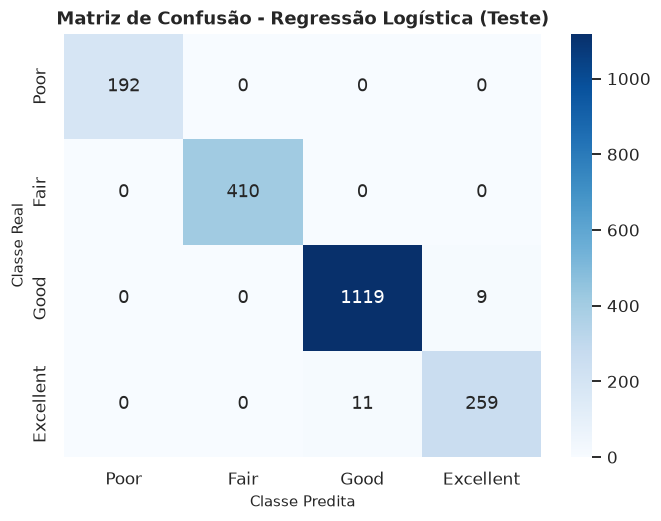

In [40]:
pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

pipe_lr.fit(X_train, y_train)


y_pred_lr_train = pipe_lr.predict(X_train)
y_pred_lr_test = pipe_lr.predict(X_test)

acc_lr_train = accuracy_score(y_train, y_pred_lr_train)
acc_lr_test = accuracy_score(y_test, y_pred_lr_test)

print(f"Acurácia Treino: {acc_lr_train:.4f} ({acc_lr_train*100:.2f}%)")
print(f"Acurácia Teste : {acc_lr_test:.4f} ({acc_lr_test*100:.2f}%)")
print("Relatório de Classificação (Conjunto de Teste):")
print(classification_report(y_test, y_pred_lr_test))

labels_ordem = ["Poor", "Fair", "Good", "Excellent"]
cm_lr = confusion_matrix(y_test, y_pred_lr_test, labels=labels_ordem)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", xticklabels=labels_ordem, yticklabels=labels_ordem)
plt.title("Matriz de Confusão - Regressão Logística (Teste)")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.show()

### 3.4 Modelo 2: Random Forest Classifier

=== Desempenho do Modelo 2: Random Forest ===
Acurácia Treino: 0.9999 (99.99%)
Acurácia Teste : 0.9910 (99.10%)
Relatório de Classificação (Conjunto de Teste):
              precision    recall  f1-score   support

   Excellent       0.99      0.94      0.97       270
        Fair       1.00      1.00      1.00       410
        Good       0.99      1.00      0.99      1128
        Poor       1.00      1.00      1.00       192

    accuracy                           0.99      2000
   macro avg       0.99      0.98      0.99      2000
weighted avg       0.99      0.99      0.99      2000



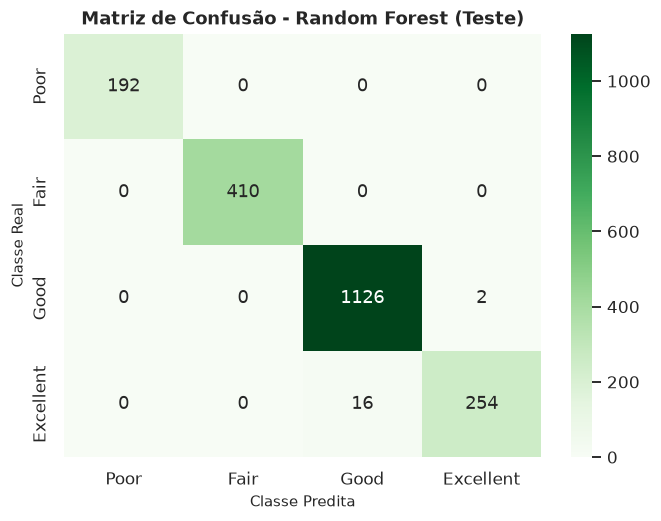

In [42]:
pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1))
])

pipe_rf.fit(X_train, y_train)

y_pred_rf_train = pipe_rf.predict(X_train)
y_pred_rf_test = pipe_rf.predict(X_test)

acc_rf_train = accuracy_score(y_train, y_pred_rf_train)
acc_rf_test = accuracy_score(y_test, y_pred_rf_test)

print("=== Desempenho do Modelo 2: Random Forest ===")
print(f"Acurácia Treino: {acc_rf_train:.4f} ({acc_rf_train*100:.2f}%)")
print(f"Acurácia Teste : {acc_rf_test:.4f} ({acc_rf_test*100:.2f}%)")
print("Relatório de Classificação (Conjunto de Teste):")
print(classification_report(y_test, y_pred_rf_test))

cm_rf = confusion_matrix(y_test, y_pred_rf_test, labels=labels_ordem)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", xticklabels=labels_ordem, yticklabels=labels_ordem)
plt.title("Matriz de Confusão - Random Forest (Teste)")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.show()

### 3.5 Comparação de Modelos e Análise de Importância das Features

,Modelo,Acurácia Treino,Acurácia Teste,Delta (Overfitting)
0,Regressão Logística,0.99,0.99,0.00
1,Random Forest,1.00,0.99,0.01


/tmp/ipykernel_9614/1068139643.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")


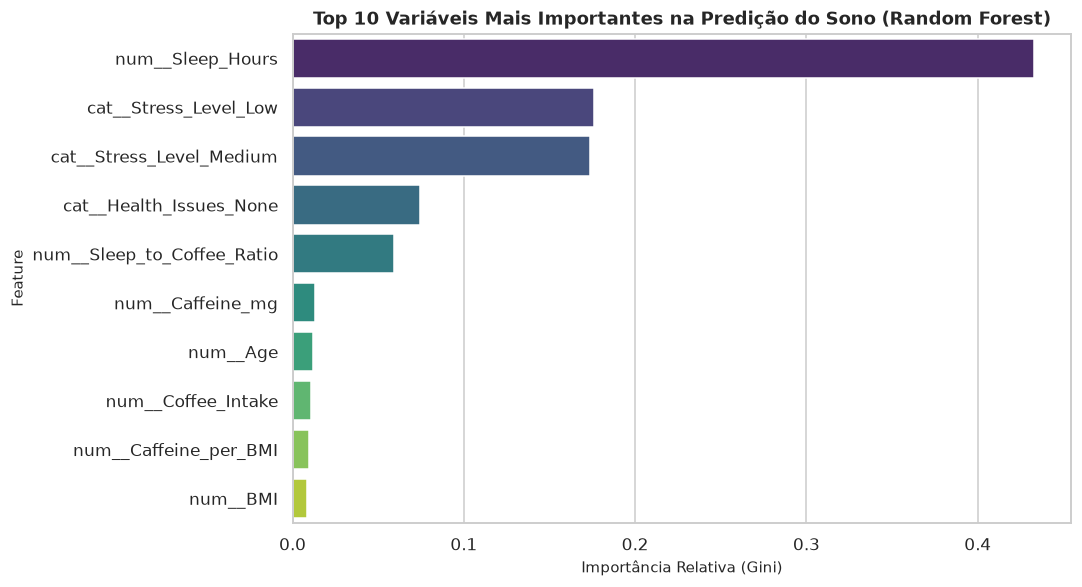

In [43]:
df_comparacao = pd.DataFrame({
    "Modelo": ["Regressão Logística", "Random Forest"],
    "Acurácia Treino": [acc_lr_train, acc_rf_train],
    "Acurácia Teste": [acc_lr_test, acc_rf_test],
    "Delta (Overfitting)": [abs(acc_lr_train - acc_lr_test), abs(acc_rf_train - acc_rf_test)]
})
display(df_comparacao)

nomes_features = pipe_rf.named_steps["preprocessor"].get_feature_names_out()
importancias = pipe_rf.named_steps["classifier"].feature_importances_

top_features = pd.Series(importancias, index=nomes_features).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5.5))
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title("Top 10 Variáveis Mais Importantes na Predição do Sono (Random Forest)")
plt.xlabel("Importância Relativa (Gini)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### 3.6 Salvamento e Teste do Melhor Modelo

In [44]:
caminho_modelo = "models/best_sleep_quality_model.joblib"
if not os.path.exists("models") and os.path.exists("../models"):
    caminho_modelo = "../models/best_sleep_quality_model.joblib"

joblib.dump(pipe_rf, caminho_modelo)
print(f" Melhor modelo serializado com sucesso em: {caminho_modelo}")


modelo_carregado = joblib.load(caminho_modelo)
amostra = X_test.iloc[:5]
predicoes_amostra = modelo_carregado.predict(amostra)

resultado_teste = pd.DataFrame({
    "Real": y_test.iloc[:5].values,
    "Predito": predicoes_amostra
})
display(resultado_teste)

 Melhor modelo serializado com sucesso em: ../models/best_sleep_quality_model.joblib


,Real,Predito
0,Fair,Fair
1,Good,Good
2,Good,Good
3,Good,Good
4,Excellent,Excellent
